In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Additional libraries for handling imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Load iris
iris = load_iris()
X = iris.data
y = iris.target

# Convert to binary class problem
y = (y == 0).astype(int)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [3]:
# Model init
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train, y_train)

# Make predictions
y_pred = lr.predict(X_test)
y_scores = lr.predict_proba(X_test)[:, 1]

In [5]:
# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Print metrics
print('Accuracy Score: ', accuracy)
print('Precision Score: ', precision)
print('Recall Score: ', recall)
print('F1 Score: ', f1)
print('Confusion Matrix:\n', cm)

Accuracy Score:  1.0
Precision Score:  1.0
Recall Score:  1.0
F1 Score:  1.0
Confusion Matrix:
 [[30  0]
 [ 0 15]]


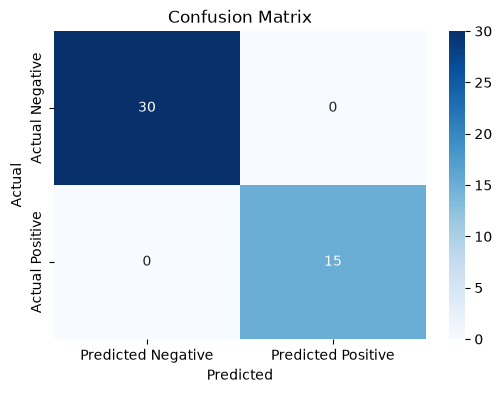

In [6]:
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative', 'Actual Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

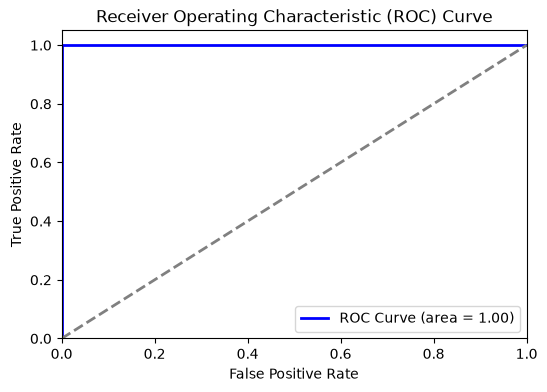

In [8]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(
    fpr,
    tpr,
    color='blue',
    lw=2,
    label='ROC Curve (area = %0.2f)' % roc_auc
)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [9]:
# Load housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [10]:
# Model init
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make prediction
y_pred = lr.predict(X_test)

In [11]:
# Compute metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print metrics
print('MAE: ', mae)
print('MSE: ', mse)
print('RMSE: ', rmse)
print('R-squared: ', r2)

MAE:  0.527247453830615
MSE:  0.5305677824766755
RMSE:  0.7284008391515454
R-squared:  0.5957702326061662


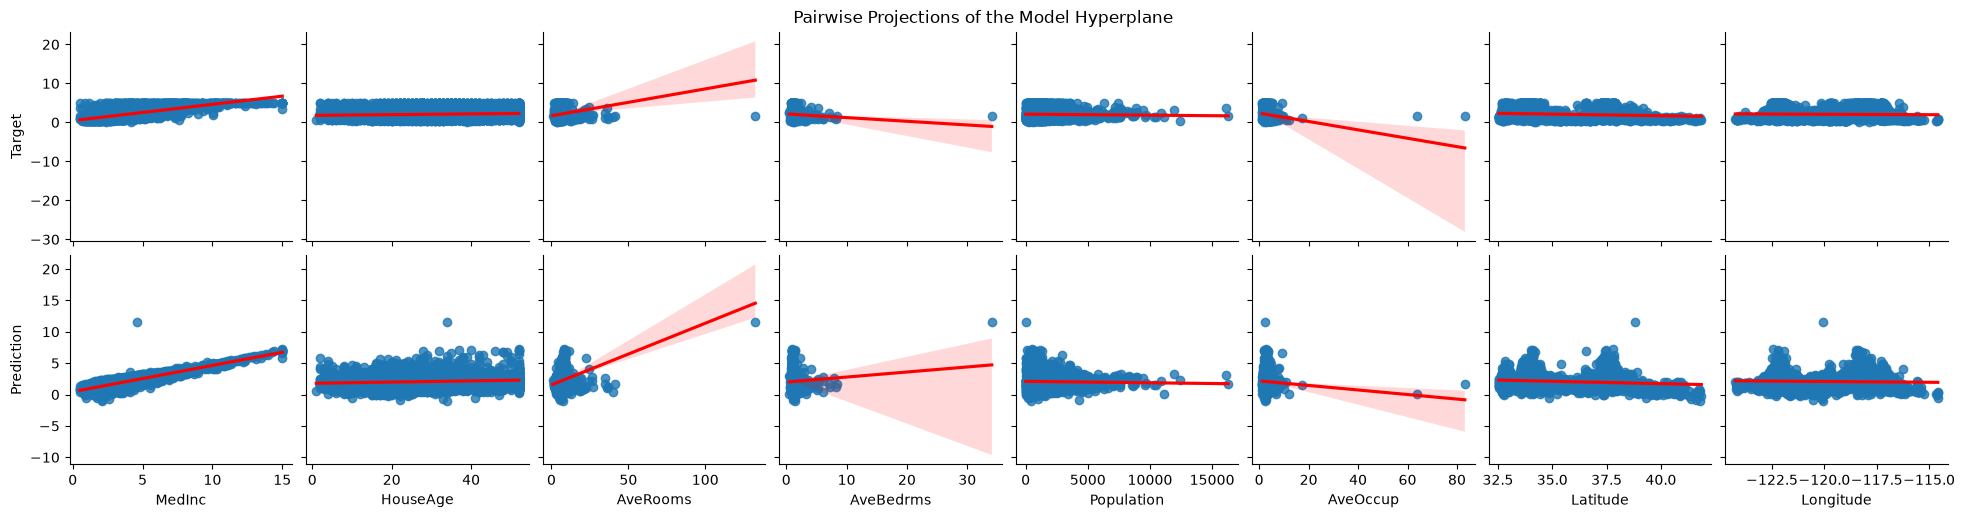

In [12]:
# Create pandas dataframe for the test set and predictions
df = pd.DataFrame(X_test, columns=housing.feature_names)
df['Target'] = y_test
df['Prediction'] = y_pred

# Plot pairwise projections
sns.pairplot(
    df,
    x_vars=housing.feature_names,
    y_vars=['Target','Prediction'],
    kind='reg',
    plot_kws={'line_kws':{'color':'red'}}
)
plt.suptitle('Pairwise Projections of the Model Hyperplane', y=1.02)
plt.show()